In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

i_94 = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
i_94.info()
i_94.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


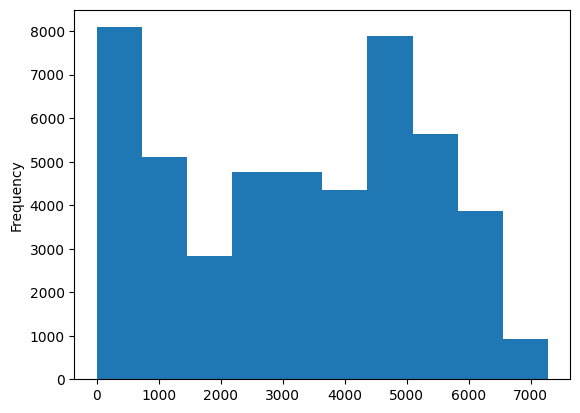

count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

In [2]:
# Display histogram and statistics of traffic volume
i_94['traffic_volume'].plot.hist()
plt.show()

i_94['traffic_volume'].describe()

In [3]:
# Convert date_time to datetime
i_94['date_time'] = pd.to_datetime(i_94['date_time'])

In [4]:
# Separate daytime (7AM-7PM) and nighttime (7PM-7AM) data
day = i_94[(i_94['date_time'].dt.hour >= 7) & (i_94['date_time'].dt.hour < 19)].copy()
print('Day shape:', day.shape)

night = i_94[(i_94['date_time'].dt.hour >= 19) | (i_94['date_time'].dt.hour < 7)].copy()
print('Night shape:', night.shape)

Day shape: (23877, 9)
Night shape: (24327, 9)


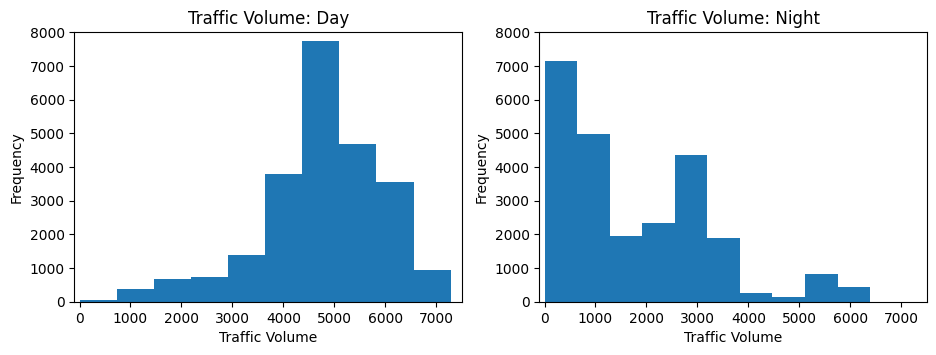

Day statistics:
count    23877.000000
mean      4762.047452
std       1174.546482
min          0.000000
25%       4252.000000
50%       4820.000000
75%       5559.000000
max       7280.000000
Name: traffic_volume, dtype: float64

Night statistics:
count    24327.000000
mean      1785.377441
std       1441.951197
min          0.000000
25%        530.000000
50%       1287.000000
75%       2819.000000
max       6386.000000
Name: traffic_volume, dtype: float64


In [5]:
# Display side-by-side histograms of traffic volume for day and night
plt.figure(figsize=(11,3.5))

plt.subplot(1, 2, 1)
plt.hist(day['traffic_volume'])
plt.xlim(-100, 7500)
plt.ylim(0, 8000)
plt.title('Traffic Volume: Day')
plt.ylabel('Frequency')
plt.xlabel('Traffic Volume')

plt.subplot(1, 2, 2)
plt.hist(night['traffic_volume'])
plt.xlim(-100, 7500)
plt.ylim(0, 8000)
plt.title('Traffic Volume: Night')
plt.ylabel('Frequency')
plt.xlabel('Traffic Volume')

plt.show()

print('Day statistics:')
print(day['traffic_volume'].describe())
print('\nNight statistics:')
print(night['traffic_volume'].describe())

In [6]:
# Extract month, year, day of week, and hour from datetime for day data
day['month'] = day['date_time'].dt.month
day['year'] = day['date_time'].dt.year
day['dayofweek'] = day['date_time'].dt.dayofweek
day['hour'] = day['date_time'].dt.hour

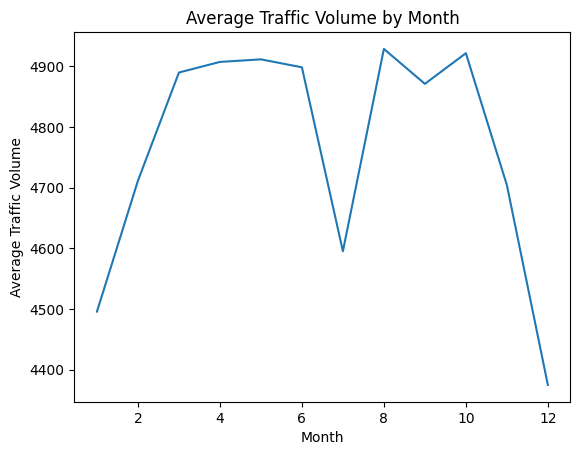

In [7]:
# Line plot showing average traffic volume by month
by_month = day.groupby('month')['traffic_volume'].mean()
by_month.plot.line()
plt.title('Average Traffic Volume by Month')
plt.xlabel('Month')
plt.ylabel('Average Traffic Volume')
plt.show()

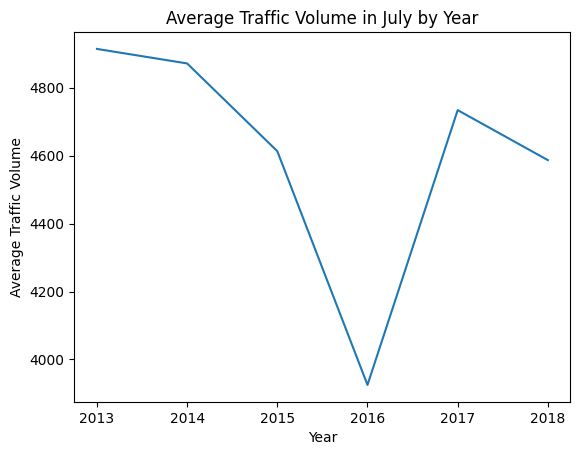

In [8]:
# Line plot showing average traffic volume in July by year
only_july = day[day['month'] == 7]
july_by_year = only_july.groupby('year')['traffic_volume'].mean()
july_by_year.plot.line()
plt.title('Average Traffic Volume in July by Year')
plt.xlabel('Year')
plt.ylabel('Average Traffic Volume')
plt.show()

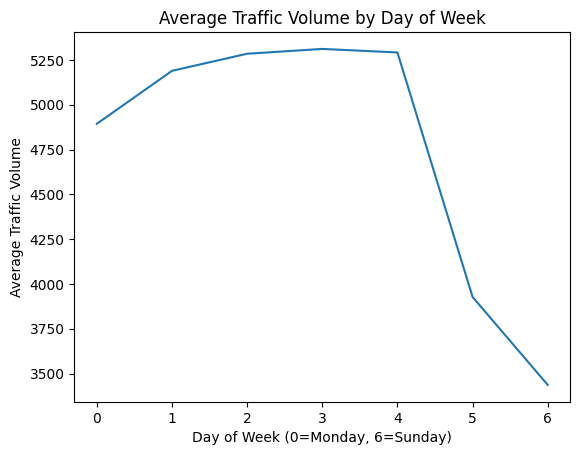

In [9]:
# Line plot showing average traffic volume by day of week
by_dayofweek = day.groupby('dayofweek')['traffic_volume'].mean()
by_dayofweek.plot.line()
plt.title('Average Traffic Volume by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Average Traffic Volume')
plt.show()

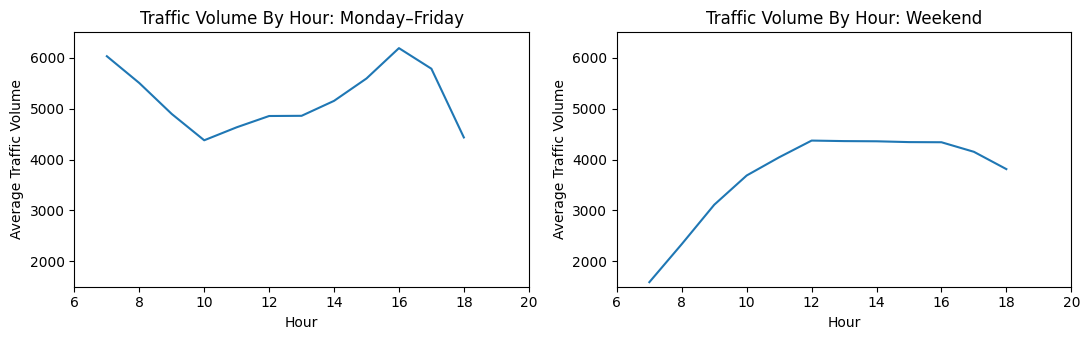

In [10]:
# Compare traffic patterns between business days and weekends
business_days = day[day['dayofweek'] <= 4].copy()
weekend = day[day['dayofweek'] >= 5].copy()
by_hour_business = business_days.groupby('hour')['traffic_volume'].mean()
by_hour_weekend = weekend.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(11,3.5))

plt.subplot(1, 2, 1)
by_hour_business.plot.line()
plt.xlim(6,20)
plt.ylim(1500,6500)
plt.title('Traffic Volume By Hour: Monday–Friday')
plt.xlabel('Hour')
plt.ylabel('Average Traffic Volume')

plt.subplot(1, 2, 2)
by_hour_weekend.plot.line()
plt.xlim(6,20)
plt.ylim(1500,6500)
plt.title('Traffic Volume By Hour: Weekend')
plt.xlabel('Hour')
plt.ylabel('Average Traffic Volume')

plt.tight_layout()
plt.show()

In [11]:
# Compute correlation between weather columns and traffic volume
numeric_cols = day.select_dtypes(include=['float64', 'int64'])
numeric_cols.corr()['traffic_volume']

temp              0.128317
rain_1h           0.003697
snow_1h           0.001265
clouds_all       -0.032932
traffic_volume    1.000000
Name: traffic_volume, dtype: float64

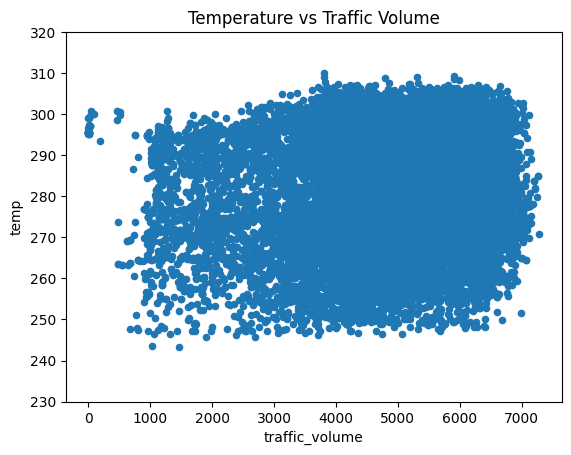

In [12]:
# Scatter plot showing relationship between temperature and traffic volume
day.plot.scatter('traffic_volume', 'temp')
plt.ylim(230, 320)
plt.title('Temperature vs Traffic Volume')
plt.show()

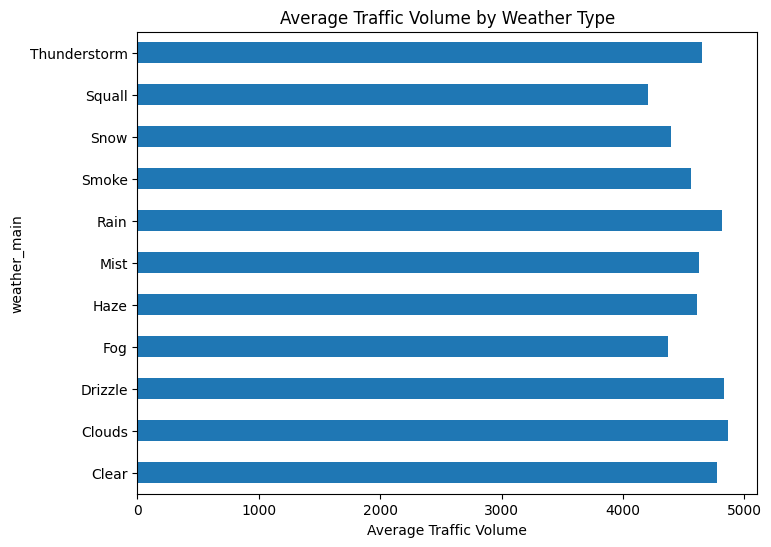

In [13]:
# Bar chart showing average traffic volume by main weather type
by_weather_main = day.groupby('weather_main')['traffic_volume'].mean()
by_weather_main.plot.barh(figsize=(8,6))
plt.title('Average Traffic Volume by Weather Type')
plt.xlabel('Average Traffic Volume')
plt.show()